In [15]:
import schemdraw
import schemdraw.elements as elm
from schemdraw import flow, logic, dsp

## Digital Architecture
Represents CDC/RDC and not on my notepad (finally)

In [ ]:
with schemdraw.Drawing() as d:
    elm.DataBusLine().dot()
    with d.hold():
        elm.Line().length(d.unit/4)
        spi = dsp.Box(w=2, h=2).anchor('W').label('SPI')
    dsp.Line().down()
    dsp.Line().right().label('SCL').dot().length(d.unit*2/3)
    
    # add SCL line to data memory
    with d.hold():
        dsp.Line().down()
        dsp.Line().right().length(d.unit*2.15)
        datamem = elm.Ic(
            pins=[elm.IcPin(name='>', side='left', slot='1/3'),
                  elm.IcPin(name='RD', side='left', slot='3/3'),
                  elm.IcPin(name='WR', side='right', slot='3/3')]
        ).anchor('>').label('MEM')

    dsp.Line().right().length(d.unit/3)
    reset = dsp.Box(w=1,h=1).label('RST')

    # create registers
    dbl = elm.DataBusLine().at(spi.E, dy=0.5).label('REG IF')
    reg = dsp.Box(w=2, h=2).at(dbl.end, dy=-0.5).label('REG')

    dsp.Line().at(spi.E, dy=-0.5).tox(reset.N)
    elm.DataBusLine().length(d.unit/2).down()
    dsp.Arrow().toy(reset.N).length(d.unit/2)
    dsp.Line().at(reset.E).length(d.unit/4).right()
    dsp.Line().up().toy(reg.W - 0.5).label('Reg reset', rotate=True)
    dsp.Arrow().right().tox(reg.W)

    # connect registers to synchronizers and memory
    dsp.Arrow().at(reg.E, dy=0.5).length(d.unit/2)
    sysclk_sync = dsp.Box(h=1,w=2).label('Sync to\nPLL clock')
    spiclk_sync = dsp.Box(h=1,w=2).at(sysclk_sync.S).anchor('N').label('Sync to\nSPI clock')
    dsp.Arrow().tox(reg.E).at(spiclk_sync.W)
    dsp.Line().at(datamem.RD).up().toy(spiclk_sync.W-0.1*d.unit).label('Mem read', rotate=True)
    dsp.Arrow().left().tox(reg.E)

    # create main state machine and connect it up
    dsp.Line().at(sysclk_sync.E).right().length(d.unit/2).dot()
    arr1 = dsp.Arrow().right().length(d.unit/2)
    main_sm = dsp.Box(h=3).at(arr1.end, dy=-1).label('Main State\nMachine')
    dsp.Arrow().at(main_sm.W).tox(spiclk_sync.E)

    # create and connect PLL
    dsp.Line().at(main_sm.S).length(d.unit/4).down()
    pll = dsp.Box(h=1,w=1).label('PLL').anchor('N')
    dsp.Line().at(pll.W, dy=0.25).left().length(d.unit/2)
    dsp.Line().up().toy(spiclk_sync.E).dot()
    dsp.Line().at(arr1.start).down().toy(pll.W-0.25)
    dsp.Line().tox(pll.W)
    dsp.Line().at(pll.E).right().label('Ref clock', loc='right').length(d.unit*2)

    # create dividing lines
    dsp.Line().at(datamem.RD, dx=0.2).up().toy(reg.N + 0.5).style(color='gray', ls='--')
    dsp.Line().at(datamem.RD, dx=0.2).down().style(color='gray', ls='--').length(d.unit*3/4)
    dsp.Line().at(datamem.WR, dx=-0.2).up().toy(reg.N + 0.5).style(color='gray', ls='--')
    dsp.Line().at(datamem.WR, dx=-0.2).down().style(color='gray', ls='--').length(d.unit*3/4)\
        .label('SPI Clock Domain', halign='right', ofst=(1.25, -3.5))\
        .label('CDC', halign='center', ofst=(1.25, -1.5))\
        .label('PLL Clock Domain', halign='left', ofst=(1.25, 0.5))
    
    # create DSP mux into memory
    dsp.Line().at(datamem.WR).right().length(d.unit/2)
    dmux = elm.intcircuits.Multiplexer(
        demux=True, 
        size=(0.5,1),
        pins=[elm.IcPin(anchorname='D', side='left'),
              elm.IcPin(anchorname='A', side='right'),
              elm.IcPin(anchorname='B', side='right')],
        edgepadH=0,
        edgepadW=0,
        lsize=0).anchor('D')
    dsp.Box(h=0.5, w=4).label('Incremental Filters').at(dmux.A)
    dsp.Line().length(d.unit/8)
    fl = dsp.Line().up().length(d.unit/6).dot()
    dsp.Line().at(dmux.B).tox(fl.end).right()
    dsp.Line().down().toy(fl.end)

    # main state machine to SAR state machine
    dsp.Line().at(main_sm.E).length(d.unit).right().dot()
    with d.hold():
        dsp.Line().length(d.unit/4)
        sar_sm = dsp.Box().anchor('W').label('SAR State\nMachine')
        dsp.Arrow().at(sar_sm.E, dx=1).left().tox(sar_sm.E).label('Comparator Input', loc='right')
        dsp.Line().at(sar_sm.N).up().length(d.unit/4)
        elm.DataBusLine().right().length(d.unit/2)
        dsp.Arrow().length(d.unit/2 - 0.5).label(r'$I^2C$ to Shift Registers', loc='right')
    elm.DataBusLine().down().toy(fl.end)
    dsp.Line().left().tox(fl.end)

## Silva-Steensgard Loop

Overall ADC topology

In [ ]:
with schemdraw.Drawing() as d:
    d.unit = 1
    dsp.Line().length(d.unit/2).dot().label('')
    
    with d.hold():
        # draw sum and first filter
        dsp.Arrow().length(d.unit/2)
        sum_err = dsp.Sum().anchor('W')
        dsp.Arrow().length(d.unit/2)
        filt1 = dsp.Box(h=1.5,w=2).label(r'$\frac{1}{1-z^{-1}}$', fontsize=18)

        # draw second filter
        f1_out = dsp.Line().length(d.unit/2).dot()
        dsp.Arrow().length(d.unit/2)
        filt2 = dsp.Box(h=1.5,w=2).label(r'$\frac{1}{1-z^{-1}}$', fontsize=18)

        # draw final delay and quantizer
        dsp.Arrow().length(d.unit/2)
        del2 = dsp.Box(h=1,w=1.5).label(r'$z^{-1}$')
        dsp.Arrow().length(d.unit/2)
        s_quant = dsp.Sum().anchor('W')
        dsp.Arrow().length(d.unit/2)

        dsp.Adc().label('SAR')
        elm.DataBusLine().length(d.unit*3/2).dot()

        with d.hold():
            dsp.Arrow().label('To Digital', loc='right').length(d.unit)

        # draw feedback
        dsp.Line().down().length(d.unit*2)
        dsp.Line().left()
        dsp.Box(h=1,w=1.5).label('DWA')
        dsp.Line().tox(filt1.E)
        dsp.Dac().label('CDAC')
        dsp.Line().tox(sum_err.S)
        dsp.Arrow().toy(sum_err.S).up()\
            .label('-', ofst=(0.6,0.25), fontsize=24)
        
    # now that we're back at start, draw feedforward
    dsp.Line().up().length(d.unit*2.5)
    dsp.Line().right().tox(s_quant.N)
    dsp.Arrow().to(s_quant.N)

    dsp.Line().up().length(d.unit*3/2).at(f1_out.end)
    dsp.Arrow().right().tox(del2.W)
    dsp.Box(h=1,w=1.5).label(r'$z^{-1}$')
    dsp.Line().length(d.unit/4)
    dsp.Arrow().to(s_quant.NW)
    

In [ ]:
with schemdraw.Drawing() as d:
    d.unit=1
    dsp.Arrow().length(d.unit).label(r'$D_1$', loc='left')
    filt1 = dsp.Box(h=1.5,w=2).label(r'$\frac{1}{1-z^{-1}}$', fontsize=18)
    dsp.Arrow().length(d.unit)
    filt2 = dsp.Box(h=1.5,w=2).label(r'$\frac{1}{1-z^{-1}}$', fontsize=18)
    dsp.Arrow().length(d.unit)
    ds = dsp.Box(h=1.5,w=2).label(r'$\downarrow OSR$', fontsize=18)
    dsp.Arrow().length(d.unit).label('To Data Mem', loc='right')

    dsp.Arrow().at(filt1.S, dy=-d.unit/2).to(filt1.S).label('RST', loc='left')
    dsp.Arrow().at(filt2.S, dy=-d.unit/2).to(filt2.S).label('RST', loc='left')


## UVM-MS Testbench

In [ ]:
with schemdraw.Drawing() as d:
    dsp.Box().label('VIN Agent').fill('navajowhite')
    dsp.Arrow().label(r'$V_{in}[k]$')
    ana = dsp.Box().label('SV Analog\n(Model)')
    dsp.Arrow().label('Comparator\nOutput')
    dut = dsp.Box().label('ADC RTL\n(DUT)')
    elm.DataBusLine().label('SPI')
    spi = dsp.Box().label('SPI Agent').fill('navajowhite')
    dsp.Arrow(double=True).length(d.unit/2)
    dsp.Box().label("UVM RAL").fill('lightblue')

    with d.hold():
        dsp.Line().length(d.unit/2).at(dut.N).up().label(r'$I^2C$')
        dsp.Line().left().length(d.unit/3)
        cpsr = dsp.Box(h=1).label('CP Shift Register\n(Model)')
        elm.DataBusLine().tox(ana.N)
        dsp.Arrow().toy(ana.N).label(r'CP $V_{DAC}$')

    with d.hold():
        dsp.Line().length(d.unit/2).at(dut.S).down().label(r'$I^2C$')
        dsp.Line().left().length(d.unit/3)
        cnsr = dsp.Box(h=1).label('CN Shift Register\n(Model)')
        elm.DataBusLine().tox(ana.S)
        dsp.Arrow().toy(ana.S).label(r'CN $V_{DAC}$')

    clkgen = dsp.Box(h=1).anchor('N').at(dut.S, dx=0.5, dy=-d.unit).label('CLKGEN Agent').fill('navajowhite')
    dsp.Arrow().at(clkgen.N).up().toy(dut.S)
    rst = dsp.Box(h=1).anchor('N').at(clkgen.S, dx=0.65).label('RESET Agent').fill('navajowhite')
    dsp.Line().at(rst.N).up().toy(clkgen.N).linestyle(':')
    dsp.Arrow().toy(dut.S)

    # boundary lines
    b = 0.35
    dsp.Line().at(ana.W, dx=-b).up().toy(cpsr.N + b).linestyle('--').color('gray')
    dsp.Line().right().tox(dut.E + b).linestyle('--').color('gray')\
        .label('Planned PCB')
    dsp.Line().down().toy(cnsr.S - b).linestyle('--').color('gray')
    dsp.Line().left().tox(ana.W - b).linestyle('--').color('gray')
    dsp.Line().up().toy(ana.W).linestyle('--').color('gray')

## SPI Protocol

In [ ]:
with schemdraw.Drawing() as d:
    logic.TimingDiagram(
        {'signal': [
            {'name': r'$\overline{CS}$', 'wave': '1.0....|....|.1.'},
            {'name': 'SCLK',             'wave': 'xln....|....|.lx'},
            {'name': 'MOSI',             'wave': 'x.32...|2...|.lx', 
             'data': ['0', 'ADDR[14:0]', 'WR DATA[15:0]']}
        ]},
        grid=False,
        ygap=0.4
    )

In [ ]:
with schemdraw.Drawing() as d:
    logic.TimingDiagram(
        {'signal': [
            {'name': r'$\overline{CS}$', 'wave': '1.0....|....|.1.'},
            {'name': 'SCLK',             'wave': 'xln....|....|.lx'},
            {'name': 'MOSI',             'wave': 'x.32...|x...|...', 
             'data': ['1', 'ADDR[14:0]']},
            {'name': 'MISO',             'wave': 'z......|2...|.z..', 'data': ['RD DATA[15:0]']}
        ]},
        grid=False,
        ygap=0.4
    )

In [ ]:
with schemdraw.Drawing() as d:
    logic.TimingDiagram(
        {'signal': [
            {'name': r'$\overline{CS}$', 'wave': '1.0...|...|....|1.'},
            {'name': 'SCLK',             'wave': 'xln...|...|....|lx'},
            {'name': 'MOSI',             'wave': 'x.32..|2..|2...|lx', 
             'data': ['0', 'ADDR[14:0]', 'WR DATA[15:0]', 'WR DATA, ADDR + 1']}
        ]},
        grid=False,
        ygap=0.4
    )

In [ ]:
with schemdraw.Drawing() as d:
    logic.TimingDiagram(
        {'signal': [
            {'name': r'$\overline{CS}$', 'wave': '1.0...|...|....|1.'},
            {'name': 'SCLK',             'wave': 'xln...|...|....|lx'},
            {'name': 'MOSI',             'wave': 'x.32..|x..|....|..', 
             'data': ['1', 'ADDR[14:0]', 'WR DATA[15:0]', 'WR DATA, ADDR + 1']},
            {'name': 'MISO',             'wave': 'z.....|2..|2...|z.', 'data': ['RD DATA[15:0]', 'RD DATA, ADDR + 1']}
        ]},
        grid=False,
        ygap=0.4
    )

## Block Diagram

In [ ]:
with schemdraw.Drawing() as d:
    dsp.Box(w=2, h=1).label('AXI')
    dsp.Line().length(d.unit/4)
    dsp.Oscillator().label('Digital Signal\nGenerator', loc='top')
    dsp.Line().length(d.unit/4)
    dsp.Box(w=1, h=1).label(r'$\Delta\Sigma$')
    dsp.Line().length(d.unit/4)
    with d.hold():
        dsp.Line().down().linestyle('--').color('gray')\
            .label('FPGA', loc='right', ofst=(-2.5, -0.75))\
            .label('PCB', loc='right', ofst=(-2.5, +0.75))
    with d.hold():
        dsp.Line().up().linestyle('--').color('gray')
    elm.DataBusLine().length(d.unit/2).label('I2C')
    dsp.Dac().label('5311')
    dsp.Arrow().label(r'$V_{in}[k]$').length(d.unit/2)
    sha = dsp.Box(h=1, w=1.5).label('SHA')
    u = dsp.Line().label(r'$V[k]$').length(d.unit/2)
    
    # draw lines with capacitors
    with d.hold():
        c1 = elm.Capacitor().up().length(d.unit*3/4)
    dsp.Line().length(d.unit/2)
    with d.hold():
        c2 = elm.Capacitor().up().length(d.unit*3/4)
    a = dsp.Line().length(d.unit/4)
    with d.hold():
        elm.DotDotDot().at(a.end, dy=d.unit*3/8, dx=-d.unit*1/16)
    dsp.Line().length(d.unit*3/4)
    with d.hold():
        c3 = elm.Capacitor().up().length(d.unit*3/4)

    # draw comparator with summing node
    dsp.Line().length(d.unit/2)
    sum_node = dsp.Sum()
    dsp.Line().length(d.unit/4)
    comp = elm.Opamp(leads=True).anchor('in2').flip()
    with d.hold():
        dsp.Line().at(comp.in1).down().length(d.unit/4)
        elm.Ground()

    # draw feedback with shift registers
    comp_out = dsp.Line().length(d.unit/4)
    with d.hold():
        dsp.Line().at(comp_out.start).up().linestyle('--').color('gray').length(d.unit*3/2+0.5)
    with d.hold():
        dsp.Line().at(comp_out.start).down().linestyle('--').color('gray')\
            .label('PCB', loc='right', ofst=(-4.5, -0.75))\
            .label('FPGA', loc='right', ofst=(-4.5, +0.75))
    dsp.Line().length(d.unit/4).label(r'$U[k]$', loc='top', ofst=(-0.45, 0.1))
    pl = dsp.Box(h=1, w=2).label('Zynq PL')
    spi = elm.DataBusLine().length(d.unit/2).label('SPI')
    dsp.Box(h=1).label('SPI to AXI')

    elm.DataBusLine().up().at(pl.N).toy(c3.end).label('I2C')
    dsp.Line().left().tox(comp_out.start)
    dsp.Line().length(d.unit/4)
    dsp.Box(h=1, w=3).label('Shift Register\n74HC595D')
    elm.DataBusLine()
    dsp.Line().tox(c1.end)

    # draw integrators
    dsp.Line().at(c1.start).down()
    dsp.Line().right().length(d.unit/4)
    dsp.Box(h=1, w=1.25).label('INT1')
    dsp.Line().length(d.unit/4)
    with d.hold():
        dsp.Line().up().length(d.unit/2)
        dsp.Arrow().to(sum_node.SW)
    dsp.Line().length(d.unit/4)
    dsp.Box(h=1, w=1.25).label('INT2')
    dsp.Line().length(d.unit/4)
    dsp.Arrow().to(sum_node.S)
    

## Main State Machine

In [ ]:
with schemdraw.Drawing() as d:
    flow.Arrow().down().length(d.unit/4).label('Reset', loc='right')
    ready = flow.Box().label('Ready')
    flow.Arrow().at(ready.E).right().label('Start = 1')
    sh_active = flow.Box().label('SH')
    flow.Arrow()
    with d.container() as sar:
        sq = flow.Box().label('SAR Quantize')
        flow.Arrow(double=True).length(d.unit/2)
        flow.Box().label(r'Shift Register\n$I^2C$')
        sar.color('blue')
        sar.linestyle('--')
        sar.label('SAR Conversion', loc='N', halign='center', valign='top')
    flow.Line().length(d.unit/2)
    flow.Arrow().down().length(d.unit/2)
    
    ns_en = flow.Decision(W='No', S='Yes').label('Integration\nEnabled?')
    arr1 = flow.Arrow().at(ns_en.W).left().tox(sh_active.E)
    nfft_done = flow.Decision(N='No', W='Yes').anchor('E').label('NFFT\nDone')
    flow.Arrow().at(nfft_done.N).up().toy(sh_active.S)
    done = flow.Box().at((ready.E[0], nfft_done.W[1])).anchor('E').label('Done')
    flow.Arrow().at(done.N).up().to(ready.S).label('Start = 0', loc='bottom')
    flow.Arrow().at(nfft_done.W).left()

    flow.Line().at(ns_en.S).down().length(d.unit/2)
    flow.Arrow().left().length(d.unit/2)
    flow.Box().label('INT1')
    flow.Arrow()
    flow.Box().label('INT2')
    flow.Line().tox(nfft_done.S)
    flow.Arrow().toy(nfft_done.S)



## Updated UVM Block Diagram

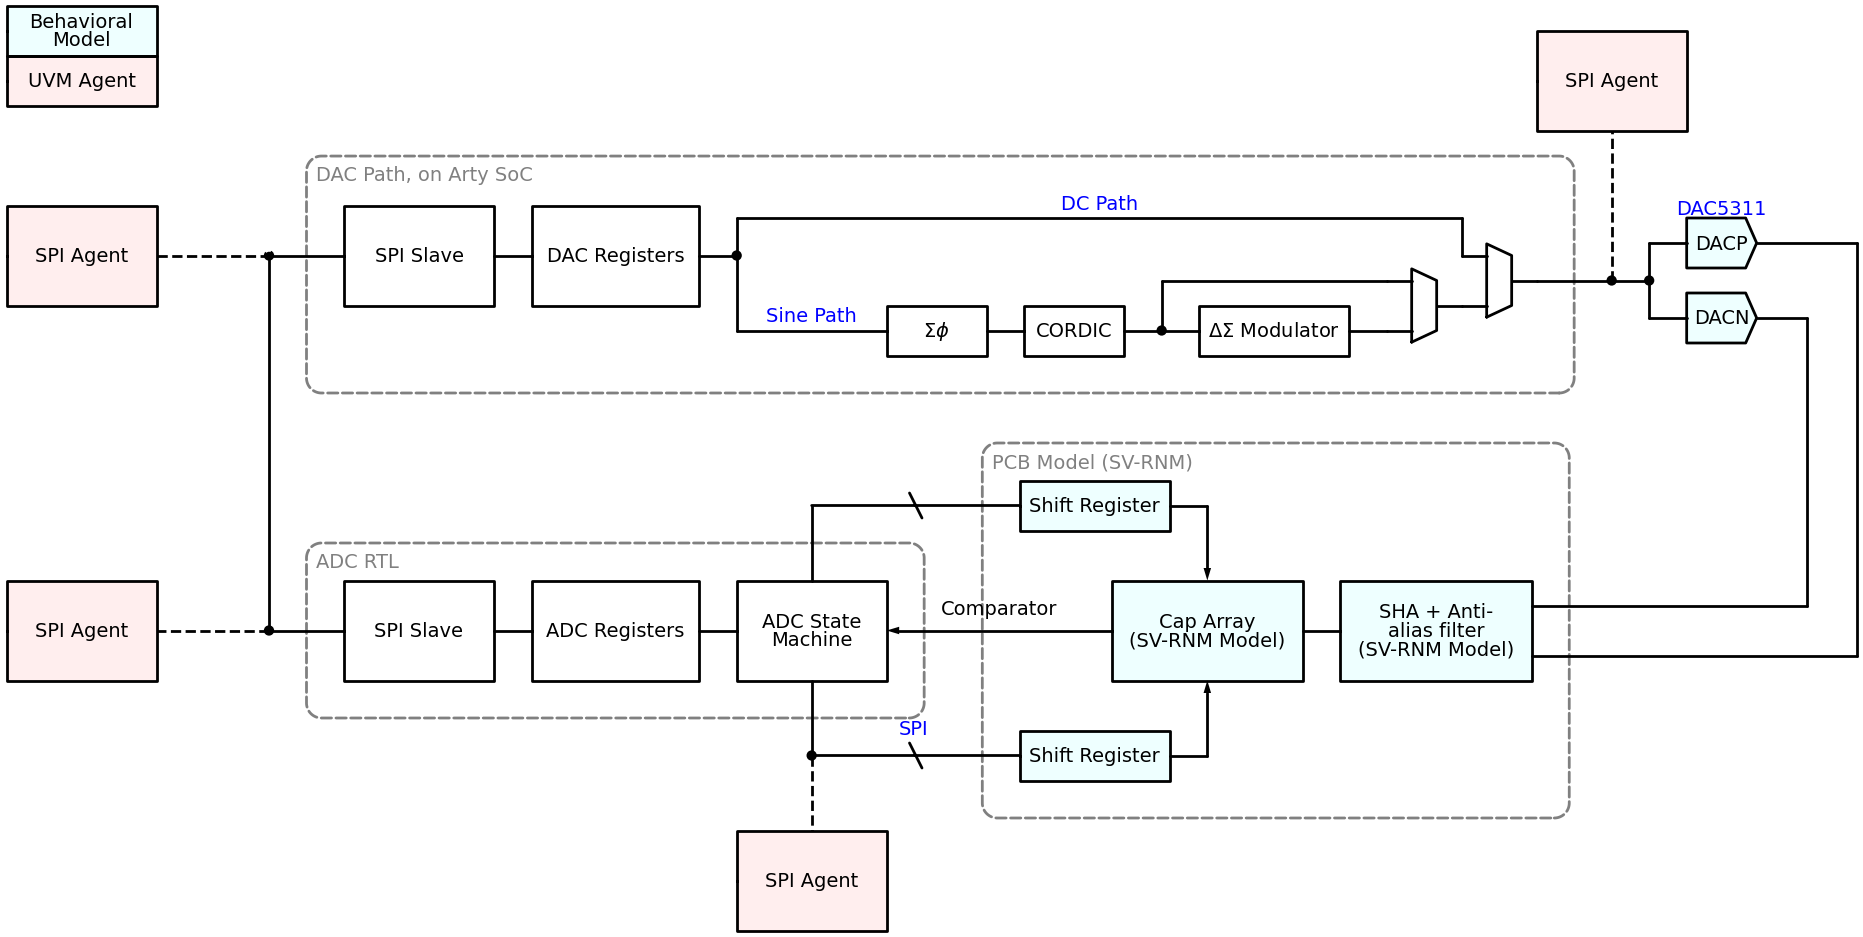

In [ ]:
agent_color='#ffeeee'
model_color='#eeffff'

with schemdraw.Drawing() as d:

    dsp.Box().label('SPI Agent').fill(agent_color)

    axi_bus = dsp.Line().length(d.unit*3/4).dot().linestyle('--')
    dsp.Line().length(d.unit/2)

    with d.container() as c:
        dac_spi = dsp.Box().label('SPI Slave')
        dsp.Line().length(d.unit/4)
        dac_registers = dsp.Box().label('DAC Registers')
        dsp.Line().length(d.unit/4).dot()

        with d.hold():
            dsp.Line().down().length(d.unit/2)
            dsp.Line().right().label('Sine Path', color='b')
            dsp.Box(w=2, h=1).label(r'$\Sigma\phi$')
            dsp.Line().right().length(d.unit/4)
            dsp.Box(w=2, h=1).label('CORDIC')
            dsp.Line().right().length(d.unit/4).dot()
            mline = dsp.Line().right().length(d.unit/4)
            dsp.Box(w=3, h=1).label(r'$\Delta\Sigma$ Modulator')
            dsp.Line().right().length(d.unit/4)

            dsm_mux = elm.intcircuits.Multiplexer(
                size=(0.5,1),
                pins=[elm.IcPin(anchorname='D', side='right'),
                    elm.IcPin(anchorname='A', side='left'),
                    elm.IcPin(anchorname='B', side='left')],
                edgepadH=0,
                edgepadW=0,
                lsize=0).anchor('A')
            
            dsp.Line().up().toy(dsm_mux.B).at(mline.start)
            dsp.Line().tox(dsm_mux.B).right()

            dc_mux = elm.intcircuits.Multiplexer(
                size=(0.5,1),
                pins=[elm.IcPin(anchorname='D', side='right'),
                    elm.IcPin(anchorname='A', side='left'),
                    elm.IcPin(anchorname='B', side='left')],
                edgepadH=0,
                edgepadW=0,
                lsize=0).anchor('A').at(dsm_mux.D)
            
        dsp.Line().up().length(d.unit/4)
        dsp.Line().right().tox(dc_mux.B).label('DC Path', color='b')
        dsp.Line().down().toy(dc_mux.B)

        c.linestyle('--')
        c.color('gray')
        c.label('DAC Path, on Arty SoC')

    dac_spiline = dsp.Line().right().length(d.unit/2).at(dc_mux.D).dot()

    with d.hold():
        dsp.Line().up().linestyle('--')
        dsp.Box().label('SPI Agent').fill(agent_color)
    dsp.Line().right().length(d.unit/4).dot()

    with d.hold():
        dsp.Line().up().length(d.unit/4)
        dsp.Line().right().length(d.unit/4)
        dacp = dsp.Dac().label('DACP').label('DAC5311', loc='top', color='b').fill(model_color)
        
    with d.hold():
        dsp.Line().down().length(d.unit/4)
        dsp.Line().right().length(d.unit/4)
        dacn = dsp.Dac().label('DACN').fill(model_color)

    dsp.Line().down().at(axi_bus.end).length(d.unit*2.5).dot()
    dsp.Line().right().length(d.unit/2)

    with d.container() as c:
        adc_spi = dsp.Box(h=2, w=3).label(r'SPI Slave')
        elm.Line().length(d.unit/4)
        dsp.Box().label('ADC Registers')
        dsp.Line().length(d.unit/4)
        adc = dsp.Box().label('ADC State\nMachine')

        c.linestyle('--')
        c.label('ADC RTL')
        c.color('gray')

    with d.hold():
        dsp.Line().left().length(d.unit*3/4).linestyle('--').at(adc_spi.W, dx=-d.unit/2)
        dsp.Box().fill(agent_color).label('SPI Agent')

    dsp.Arrow(arrow='<-').length(d.unit*6/4).label('Comparator')

    with d.container() as c:
        sv_model = dsp.Box().label('Cap Array\n(SV-RNM Model)').fill(model_color)
        dsp.Line().right().length(d.unit/4)
        sha = dsp.Box().label('SHA + Anti-\nalias filter\n(SV-RNM Model)').fill(model_color)
        dsp.Arrow(arrow='<-').up().length(d.unit/2).at(sv_model.N)
        dsp.Line().left().length(d.unit/4)
        shregp = dsp.Box(h=1, w=3).label('Shift Register').fill(model_color)
        
        dsp.Arrow(arrow='<-').down().length(d.unit/2).at(sv_model.S)
        dsp.Line().left().length(d.unit/4)
        shregn = dsp.Box(h=1, w=3).label('Shift Register').fill(model_color)

        c.linestyle('--')
        c.label('PCB Model (SV-RNM)')
        c.color('gray')

    elm.DataBusLine().left().at(shregp.W).tox(adc.N)
    dsp.Line().toy(adc.N).down()
    elm.DataBusLine().left().at(shregn.W).tox(adc.N).label('SPI', color='b').dot()
    with d.hold():
        dsp.Line().down().length(d.unit/2).linestyle('--')
        dsp.Box().label('SPI Agent').fill(agent_color)
    dsp.Line().toy(adc.S).up()

    dsp.Line().at(sha.E, dy=0.5).right(d.unit*4/2-0.5)
    dsp.Line().up().toy(dacn.out)
    dsp.Line().left().tox(dacn.out)

    dsp.Line().at(sha.E, dy=-0.5).right(d.unit*4/2+0.5)
    dsp.Line().up().toy(dacp.out)
    dsp.Line().left().tox(dacp.out)

    # Add legend
    behav_legend = dsp.Box(h=1).at(axi_agent.W, dy=d.unit*1.5).right().label('Behavioral\nModel').anchor('W').fill(model_color)
    dsp.Box(h=1).at(behav_legend.S).label('UVM Agent').anchor('N').fill(agent_color)

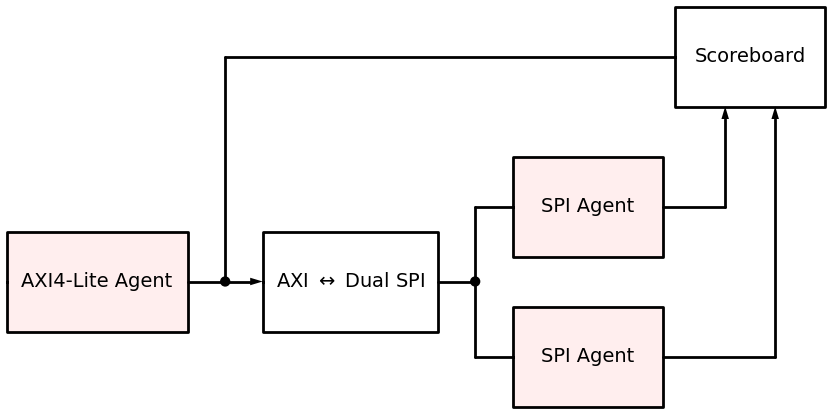

In [36]:
with schemdraw.Drawing() as d:
    dsp.Box().label('AXI4-Lite Agent').fill(agent_color)
    dsp.Line().length(d.unit/4).dot()
    arr1 = dsp.Arrow().length(d.unit/4)
    dsp.Box(w=3.5).label(r'AXI $\leftrightarrow$ Dual SPI')
    dsp.Line().length(d.unit/4).dot()

    with d.hold():
        dsp.Line().up().length(d.unit/2)
        dsp.Line().right().length(d.unit/4)
        spi1 = dsp.Box().label('SPI Agent').fill(agent_color)
    
    with d.hold():
        dsp.Line().down().length(d.unit/2)
        dsp.Line().right().length(d.unit/4)
        spi2 = dsp.Box().label('SPI Agent').fill(agent_color)

    dsp.Line().up().at(arr1.start).length(d.unit*1.5)
    dsp.Line().right().length(d.unit*3)
    sb = dsp.Box().label('Scoreboard')

    dsp.Line().at(spi1.E).right().tox(sb.S - 0.5)
    dsp.Arrow().up().toy(sb.S)

    dsp.Line().at(spi2.E).right().tox(sb.S + 0.5)
    dsp.Arrow().up().toy(sb.S)



<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1523/4067160346.py:6: SyntaxWarning: invalid escape sequence '\l'
  dsp.Box(w=3).label('AXI $\leftrightarrow$ SPI')


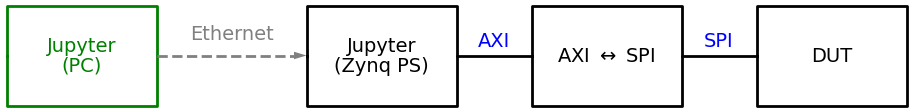

In [ ]:
with schemdraw.Drawing() as d:
    dsp.Box().label('Jupyter\n(PC)').color('green')
    dsp.Arrow().linestyle('--').label('Ethernet').color('gray')
    dsp.Box().label('Jupyter\n(Zynq PS)')
    dsp.Line().length(d.unit/2).label('AXI', color='blue')
    dsp.Box(w=3).label('AXI $\leftrightarrow$ SPI')
    dsp.Line().length(d.unit/2).label('SPI', color='blue')
    dsp.Box(w=3).label('DUT')

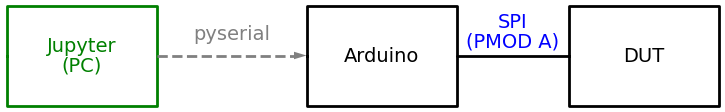

In [ ]:
with schemdraw.Drawing(show=False) as d:
    dsp.Box().label('Jupyter\n(PC)').color('green')
    dsp.Arrow().linestyle('--').label('pyserial').color('gray')
    dsp.Box().label('Arduino')
    dsp.Line().length(d.unit*3/4).label('SPI\n(PMOD A)', color='blue')
    dsp.Box(w=3).label('DUT')